# 降噪扩散概率模型 (Denoising Diffusion Probabilistic Models, DDPM)

正如你所看到的，[上一个示例](./01-vae-cn.ipynb) VAE 是一种一步生成模型。现在我们继续探讨更强大的生成模型。<br>
在这个教程中，我们将通过研究著名的降噪扩散模型之一——**降噪扩散概率模型 (DDPM)**，开始探索**扩散模型**。扩散模型将数据生成视为一个渐进细化的过程，这使得这类模型更加稳定且易于训练。

DDPM 在编码器-解码器架构中应用增量更新（一系列转换），其中编码器步骤的序列称为**前向过程** (`forward process`)，解码器步骤的序列称为**逆向过程** (`reverse process`)。(有关原始论文，请参阅 [[Ho et al., 2020](https://arxiv.org/pdf/2006.11239)]。DDPM 的灵感来源于早期的工作 [[Sohl-Dickstein et al., 2015](https://arxiv.org/pdf/1503.03585)]，该工作提出了构建一系列转换而不是一步式过程。) <br>
在 VAE 中，我们在编码步骤中将图像转换到**潜在空间**（具有更小、更简洁的维度）。然而，在 DDPM 中，我们将在前向过程中制造噪声（即加噪），并在逆向过程中去除噪声（即降噪）。

![加噪和降噪](./assets/ddpm.png)

*摘自 : "[Denoising Diffusion Probabilistic Models](https://arxiv.org/pdf/2006.11239)"*

我们的目标是建立合适的逆向过程，以便通过降噪来生成图像。

---

## 架构与方法 (Architecture & Method)

让我们结合原始论文 [[Ho et al., 2020](https://arxiv.org/pdf/2006.11239)]，简要了解降噪扩散概率模型 (DDPM) 背后的理论知识。

首先，DDPM 中的每一次增量更新都构成了一个概率马尔可夫链。(见下文。)<br>
这种架构也称为变分扩散模型 (variational diffusion models)。

![DDPM 总体架构](./assets/ddpm_architecture.png)

在这个结构中，起点 $\mathbf{x}_0$ 是原始图像（没有噪声）。

它有两条路径——一条称为**前向过程**，另一条称为**逆向过程**。(见上图。)<br>
前向过程被实现为一系列加噪步骤的链。前向过程中的每一步都通过应用 $q(\mathbf{x}_t|\mathbf{x}_{t-1})$ 来添加高斯噪声。<br>
正如你在 [VAE 示例](./01-vae-cn.ipynb) 中看到的，下一个状态 $\mathbf{x}_t$ 是由 $p(\mathbf{x}_t) = p(\mathbf{x}_{t-1}) q(\mathbf{x}_t|\mathbf{x}_{t-1})$ 随机给出的。<br>
相反，逆向过程被实现为一系列降噪步骤的链。逆向过程中的每一步都通过应用 $p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$ 来降噪，其中 $\theta$ 是可训练的参数。<br>
与上面类似，每一步中降噪后的图像也由 $p(\mathbf{x}_{t-1}) = p(\mathbf{x}_t) p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$ 给出。

> 注意 : 值得注意的是，$p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$ 是一个对于所有 $t=1,2,\ldots,T$ 共享的单个神经网络（或函数）。

此外，与 [VAE](./01-vae-cn.ipynb) 中相同，最终状态 $\mathbf{x}_T$ 被假设为 $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$。

### 1. 定义用于添加高斯噪声的前向过程 $q(\mathbf{x}_t|\mathbf{x}_{t-1})$

为了在前向过程中添加噪声，我们应用以下条件分布（它依赖于前一个状态 $\mathbf{x}_{t-1}$）。<br>
与 [VAE](./01-vae-cn.ipynb) 不同，这种添加噪声的分布 $q(\mathbf{x}_t|\mathbf{x}_{t-1})$ 没有可学习的参数。

$\displaystyle q(\mathbf{x}_t|\mathbf{x}_{t-1}) \stackrel{\mathrm{def}}{=} \mathcal{N}(\mathbf{x}_t|\sqrt{\alpha_t}\mathbf{x}_{t-1},(1-\alpha_t)\mathbf{I}) \;\;\;\;\;\; (1)$

其中 $\alpha_t$ ($t=1,2,\ldots,T$) 是一个常数（取决于步骤 $t$），满足 $0 < \alpha_t < 1$。

你可能会想，这个公式是如何推导出来的呢？<br>
原因在于：<br>
为了最终收敛到 $\mathcal{N}(\mathbf{0}, \mathbf{I})$，我们首先定义条件分布 $q_{\phi}(\mathbf{x}_t|\mathbf{x}_{t-1})$ 如下，其中包含缩放因子 $\sqrt{\alpha_t}$。

$q_{\phi}(\mathbf{x}_t|\mathbf{x}_{t-1})= \mathcal{N}(\mathbf{x}_t|\sqrt{\alpha_t}\mathbf{x}_{t-1},\sigma^2\mathbf{I})$

在这个假设下，已知 $\sigma^2$ 应满足 $\sigma^2 = 1-\alpha_t$ 才能在 $t \to \infty$ 时收敛到 $\mathbf{x}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$。（换句话说，如果 $\sigma^2 \neq 1-\alpha_t$，那么 $\mathbf{x}_t \not\sim \mathcal{N}(\mathbf{0}, \mathbf{I}) \;\;\; (t \to \infty)$。)<br>
这就是公式 (1) 被建立的原因。

根据公式 (1)，值得注意的是，使用 $\epsilon \in \mathcal{N}(\mathbf{0}, \mathbf{I})$，$\mathbf{x}_t$ 可以写成如下形式：

$\displaystyle \mathbf{x}_t = \sqrt{\alpha_t} \mathbf{x}_{t-1} + \sqrt{1 - \alpha_t} \epsilon$

当缩放因子 $\sqrt{\alpha_t}$ 接近 0 时，分布会立即趋向于 $\mathcal{N}(\mathbf{0}, \mathbf{I})$。（相反，当缩放因子 $\sqrt{\alpha_t}$ 接近 1 时，它会保持当前的分布。）

在这些假设下，条件分布 $q(\mathbf{x_t}|\mathbf{x_0})$ 可以由下式给出：

$\displaystyle q(\mathbf{x_t}|\mathbf{x_0}) = \mathcal{N}(\mathbf{x_t}|\sqrt{\overline{\alpha}_t}\mathbf{x}_0, (1-\overline{\alpha}_t)\mathbf{I}) \;\;\;\;\;\; (2)$

其中 $\overline{\alpha}_t = \prod_{i=1}^t \alpha_i$

(此处我跳过此公式的证明。)

因此，使用 $\epsilon \in \mathcal{N}(\mathbf{0}, \mathbf{I})$，$\mathbf{x}_t$ 也可以写成如下形式。

$\displaystyle \mathbf{x}_t=\sqrt{\overline{\alpha}_t} \mathbf{x}_0 + \sqrt{1-\overline{\alpha}_t} \epsilon \;\;\;\;\;\; (3)$

### 2. 构建逆向过程 $p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$

现在轮到逆向过程 $p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$ 了。<br>
逆向过程中的每一步都应该与相应的每个前向步骤耦合。

为此，首先让我们考虑 $q(\mathbf{x}_{t-1}|\mathbf{x}_t, \mathbf{x}_0)$ 是如何建立的。<br>
因为贝叶斯定理给出 $q(\mathbf{x}_{t-1}|\mathbf{x}_t)=\frac{q(\mathbf{x}_t|\mathbf{x}_{t-1})q(\mathbf{x}_{t-1})}{q(\mathbf{x}_t)}$，所以

$\displaystyle q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)=\frac{q(\mathbf{x}_t|\mathbf{x}_{t-1}, \mathbf{x}_0)q(\mathbf{x}_{t-1}|\mathbf{x}_0)}{q(\mathbf{x}_t|\mathbf{x}_0)}$

将 (1) 和 (2) 代入右侧的每个元素，我们可以得到以下公式：

$\displaystyle q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)=\mathcal{N}(\mathbf{x}_{t-1}|\tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0),\tilde{\beta}_t\mathbf{I}) \;\;\;\;\;\; (4)$

其中 $\displaystyle \tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0)=\frac{(1-\alpha_t)\sqrt{\overline{\alpha}_{t-1}}}{1-\overline{\alpha}_t} \mathbf{x}_0 + \frac{(1-\overline{\alpha}_{t-1})\sqrt{\alpha_t}}{1-\overline{\alpha}_t} \mathbf{x}_t$ 且 $\displaystyle \tilde{\beta}_t=\frac{(1-\alpha_t)(1-\overline{\alpha}_{t-1})}{1-\overline{\alpha}_t}$

因此，我们现在将 $p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$ 定义如下：

$\displaystyle p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t) \stackrel{\mathrm{def}}{=} \mathcal{N}(\mathbf{x}_{t-1}|\mu_{\theta}(\mathbf{x}_t, t),\sigma_t^2 \mathbf{I})$

其中 $\mu_{\theta}(\mathbf{x}_t, t)$ 是一个由 $\theta$ 参数化的神经网络（或函数），且 $\displaystyle \sigma_t^2 = \frac{(1-\alpha_t)(1-\overline{\alpha}_{t-1})}{1-\overline{\alpha}_t}$。

值得注意的是，$\mu_{\theta}(\mathbf{x}_t, t)$ 的输出不仅依赖于 $\mathbf{x}_t$，还依赖于步骤 $t$。（在实现中，我们可以通过应用**时间步嵌入** (`timestep embedding`) 来实现神经网络 $p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)$。

对于这个神经网络，官方代码库实现中使用了带有注意力块的 **U-Net** 模型。（稍后我将向你展示有关此架构的详细信息。）

### 3. $\theta$ 的优化（变分下界 (variational bound) 的优化）

正如我们在 [VAE 示例](./01-vae-cn.ipynb) 中看到的，让我们考虑通过最大化 $\log p_{\theta}(\mathbf{x}_0)$ 来优化 $\theta$。（即，最小化负对数似然 $-\log p_{\theta}(\mathbf{x}_0)$ 作为损失函数）

首先，因为 $\displaystyle \log p_{\theta}(\mathbf{x}_0) = \log \int p_{\theta}(\mathbf{x}_{0:T}) d \mathbf{x}_{1:T}$（边际概率），$-\log p_{\theta}(\mathbf{x}_0)$ 的期望是：

$\displaystyle \mathbb{E}[-\log p_{\theta}(\mathbf{x}_0)] = \log \mathbb{E}_{q(\mathbf{x}_{1:T}|\mathbf{x}_0)} \left[ -\frac{p_{\theta}(\mathbf{x}_{0:T})}{q(\mathbf{x}_{1:T}|\mathbf{x}_0)} \right]$

$Jensen 不等式$表明，当 $\varphi(\cdot)$ 是凹函数时，$\varphi(\mathbb{E}[X]) \geq \mathbb{E}[\varphi(X)]$。<br>
通过应用这一点，我们现在得到：

$\displaystyle \mathbb{E}[-\log p_{\theta}(\mathbf{x}_0)] \leq \mathbb{E}_{q(\mathbf{x}_{1:T}|\mathbf{x}_0)} \left[ -\log \frac{p_{\theta}(\mathbf{x}_{0:T})}{q(\mathbf{x}_{1:T}|\mathbf{x}_0)} \right]$

通过应用 [原始论文](https://arxiv.org/pdf/2006.11239) 附录 A 的转换，我们得到：

$\displaystyle \mathbb{E}[-\log p_{\theta}(\mathbf{x}_0)] \leq \mathbb{E}_{q(\mathbf{x}_{1:T}|\mathbf{x}_0)} \left[ -\log \frac{p_{\theta}(\mathbf{x}_{0:T})}{q(\mathbf{x}_{1:T}|\mathbf{x}_0)} \right]$

$\displaystyle = D_{KL}(q(\mathbf{x}_T|\mathbf{x}_0)\|p(\mathbf{x}_T)) + \sum_{t>1} \mathbb{E}_{q(\mathbf{x}_t|\mathbf{x}_0)} \left[ D_{KL}(q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)\|p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)) \right] - \mathbb{E}_{q(\mathbf{x}_1|\mathbf{x}_0)} \left[ \log p_{\theta}(\mathbf{x}_0|\mathbf{x}_1) \right] \;\;\;\;\;\; (5)$

这个公式 (5) 代表了这个问题中的**证据下界 (ELBO)**。

对于第一项 $D_{KL}(q(\mathbf{x}_T|\mathbf{x}_0)\|p(\mathbf{x}_T))$，我们可以忽略它，因为我们在 $q(\mathbf{x}_T|\mathbf{x}_0)$ 中没有任何可学习的参数，并且我们已经设置了 $\alpha_t$（一个常数），使其在 $t \to \infty$ 时变为 $\mathbf{x}_t \sim \mathcal{N}(\mathbf{0}, \mathbf{I}) (=p(\mathbf{x}_T))$。（见上文）

对于第二项，分母和分子都是已知的高斯分布（见上文 (4)），然后我们可以计算并得到：

$\displaystyle \mathbb{E}_{q(\mathbf{x}_t|\mathbf{x}_0)} \left[ D_{KL}(q(\mathbf{x}_{t-1}|\mathbf{x}_t,\mathbf{x}_0)\|p_{\theta}(\mathbf{x}_{t-1}|\mathbf{x}_t)) \right] = \mathbb{E}_{q(\mathbf{x}_t|\mathbf{x}_0)} \left[ \frac{1}{2 \sigma_t^2} \| \tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0) - \mu_{\theta}(\mathbf{x}_t, t) \|^2 \right] + C$

其中 $C$ 是一个常数。

> 注意 : 在这个公式中，$\tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0)$ 来自前向过程 $q()$。（见上面的公式 (4)）<br>
> 而 $\mu_{\theta}(\mathbf{x}_t, t)$ 和 $\sigma_t^2$ 来自逆向过程 $p_{\theta}()$。

这意味着第二项中 $\mu_{\theta}$ 的优化是为了**预测前向过程的均值**，即 $\tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0)$。

对于第三项，根据 $p_{\theta}()$ 的定义（见上文），我们可以得到如下结果：

$\displaystyle \mathbb{E}_{q(\mathbf{x}_1|\mathbf{x}_0)}[\log p_{\theta}(\mathbf{x}_0|\mathbf{x}_1)] = -\mathbb{E}_{q(\mathbf{x}_1|\mathbf{x}_0)}\left[\frac{\| \mathbf{x}_0 - \mu_{\theta}(\mathbf{x}_1, 1) \|^2}{2 \sigma_1^2} + \frac{d}{2} \log (2\pi\sigma_1^2)\right] $

其中 $d$ 是维度数量。

这意味着第三项中 $\mu_{\theta}$ 的优化是为了**预测原始图像 $\mathbf{x}_0$**。<br>
当我们假设 $\overline{\alpha}_0=1$ 时，这也等同于预测 $\tilde{\mu}_1(\mathbf{x}_1,\mathbf{x}_0) = \mathbf{x}_0$。

这就是 DDPM 的精妙之处，因为我们在优化中所要做的就是**最小化所有 $\mathbf{x}_t$ ($t=1,2,\ldots,T$) 的采样 $\tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0)$ 和 $\mu_{\theta}(\mathbf{x}_t, t)$ 之间的总损失**（带有权重 $\frac{1}{2 \sigma_t^2}$）。

![优化 DDPM](./assets/ddpm_optimize.png)

### 4. 用于降噪的重参数化 (Reparameterization)

在上面的优化中，我们应该预测所有步骤中的均值，即 $\mu_{\theta}(\mathbf{x}_t, t)$ ($t=1,2,\ldots,T$)。<br>
通过应用重参数化，我们最终转换为**预测噪声 $\epsilon_{\theta}(\mathbf{x}_t, t)$**。（这就是为什么它被称为“降噪”扩散概率模型！）

> 注意 : 因为 $q(\mathbf{x}_t|\mathbf{x}_0)$ 没有任何可学习的参数，所以你不需要应用重参数化来使优化可行。（你可以应用梯度方法来优化 $\mu_{\theta}(\mathbf{x}_t, t)$，而无需重参数化。）<br>
> 然而，通过应用这种重参数化，算法得到了极大的简化。

为此，我们考虑使用 $\mathbf{x}_t$ 和 $\epsilon$（一个噪声）来表示 $\tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0)$（它是在步骤 $t$ 上的均值）。

回顾公式 (3)，我们有：

$\displaystyle \mathbf{x}_0=\frac{\mathbf{x}_t - \sqrt{1-\overline{\alpha}_t}\epsilon}{\sqrt{\overline{\alpha}_t}}$

因此，$\tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0)$ 可以写成：

$\displaystyle \tilde{\mu}_t(\mathbf{x}_t,\mathbf{x}_0)$

$\displaystyle =\frac{(1-\alpha_t)\sqrt{\overline{\alpha}_{t-1}}}{1-\overline{\alpha}_t} \mathbf{x}_0 + \frac{(1-\overline{\alpha}_{t-1})\sqrt{\alpha_t}}{1-\overline{\alpha}_t} \mathbf{x}_t$

$\displaystyle =\frac{(1-\alpha_t)\sqrt{\overline{\alpha}_{t-1}}}{1-\overline{\alpha}_t} \left( \frac{\mathbf{x}_t - \sqrt{1-\overline{\alpha}_t}\epsilon}{\sqrt{\overline{\alpha}_t}} \right) + \frac{(1-\overline{\alpha}_{t-1})\sqrt{\alpha_t}}{1-\overline{\alpha}_t} \mathbf{x}_t$

$\displaystyle =\frac{1}{\sqrt{\alpha}_t} \left( \mathbf{x}_t - \frac{1-\alpha_t}{\sqrt{1-\overline{\alpha}_t}}\epsilon \right)$

现在我们定义一个神经网络（或函数）$\epsilon_{\theta}(\mathbf{x}_t, t)$ 如下，其输出取决于采样 $\mathbf{x}_t$（在前向过程中生成）以及步骤 $t$。

$\displaystyle \mu_{\theta}(\mathbf{x}_t, t) = \frac{1}{\sqrt{\alpha}_t} \left( \mathbf{x}_t - \frac{1-\alpha_t}{\sqrt{1-\overline{\alpha}_t}}\epsilon_{\theta}(\mathbf{x}_t, t) \right) $

> 注意 : 为了告诉 $\epsilon_{\theta}()$ 是在哪一步生成 $\mathbf{x}_t$ 的，我们还应该提供 $t$ 作为输入。

以下是通过采样进行优化的最终过程。

1. 初始化 $T$ 和 $\alpha_t$ ($t=1,\ldots,T$)
2. 在训练集中选取 $\mathbf{x}_0$。
3. 选取时间步 $t$，例如 $t \sim \verb|Uniform|(\{1,\ldots,T\})$
4. 生成噪声的种子 $\epsilon$，例如 $\epsilon \sim \mathcal{N}(\mathbf{0},\mathbf{I})$
5. 计算 $\mathbf{x}_t = \sqrt{\overline{\alpha}_t}\mathbf{x}_0 + \sqrt{1-\overline{\alpha}_t}\epsilon$
6. 对 $\nabla_{\theta} \| \epsilon - \epsilon_{\theta}(\mathbf{x}_t, t) \|^2$ 执行梯度下降步骤
7. 重复步骤 2 - 6 直到收敛

一旦训练（优化）完成，你可以按如下方式顺序预测噪声 $\epsilon_{\theta}(\mathbf{x}_t, t)$ 和降噪图像 $\mathbf{x}_t$。

1. 选取白噪声 $\mathbf{x}_T$，例如 $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0},\mathbf{I})$
2. 循环以下过程 $t=T,\ldots,1$
    - 选取 $\mathbf{z}$，例如当 $t>1$ 时 $\mathbf{z} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$，否则 $\mathbf{z} = \mathbf{0}$
    - $\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{1-\alpha_t}{\sqrt{1-\overline{\alpha}_t}} \epsilon_{\theta}(\mathbf{x}_t,t) \right) + \sigma_t \mathbf{z}$

获得的（生成的）$\mathbf{x}_0$ 将成为最终的无噪声图像。

<blockquote>
注意 : 在这里我不多赘述，但后续的$潜在扩散模型$(`Latent Diffusion Model`) 是扩散模型的一个改进版本，它具有 VAE 和扩散的混合架构。<br>
通过编码像素空间中的表示，扩散过程可以在低维潜在空间中执行，而不是在像素空间中。在这种架构中，VAE 编码器 $\mathcal{E}$ 将像素图像编码成潜在表示（语义表示），解码器 $\mathcal{D}$ 从潜在表示中重建像素图像。<br>
它使我们能够进行高分辨率图像合成，因为它在低维潜在空间中执行并减少了开销。

![潜在扩散模型](./assets/latent_diffusion.png)

*摘自 : "[High-Resolution Image Synthesis with Latent Diffusion Models](https://arxiv.org/pdf/2112.10752)"*

在潜在扩散模型中，视觉网络（如 U-Net）不一定用作降噪模型，基于 Transformer 的模型也可以用作降噪模型。（请参阅 [Diffusion Transformer](https://arxiv.org/pdf/2212.09748)，简称 DiT。）<br>
Stable Diffusion 和 DALL-E 是潜在扩散模型的可扩展版本。
</blockquote>

---

## 构建和训练模型 (Build and Train model)

现在让我们逐步查看代码（实现）以及理论方面的描述。

在我们开始之前，我们需要安装所需的包。

In [ ]:
!pip install torch torchvision numpy matplotlib tqdm

## 构建和训练模型 (Build and Train model)

现在让我们逐步查看代码（实现）以及理论方面的描述。

在我们开始之前，我们需要安装所需的包。

### 1. 加载数据

我们加载图像 (CIFAR-10) 数据集和数据加载器。<br>
每个批次具有形状 ```[batch_size, 3, 32 32]```。

In [1]:
import torch
from torchvision import datasets, transforms

batch_size = 128

dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]))
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


现在我展示 100 个示例。

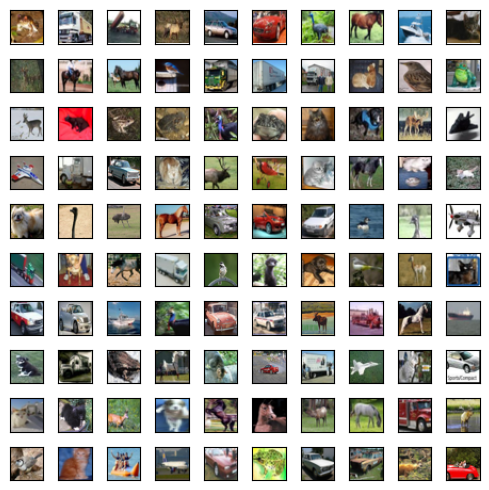

In [3]:
import numpy as np
import matplotlib.pyplot as plt

"""
for _, (data, _) in enumerate(loader):
    images = data[:3]
    break
for i in images:
    channel_last = np.transpose(i.numpy(), (1, 2, 0)) # (C, H, W) --> (H, W, C)
    plt.figure(figsize = (0.4,0.4))
    plt.imshow(channel_last)
    plt.show()
"""
num_row = 10
num_col = 10
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
tmp_loader = torch.utils.data.DataLoader(dataset, batch_size=num_row*num_col, shuffle=False)
for data, _ in tmp_loader:
    for i in range(num_row*num_col):
        image = data[i].numpy()
        channel_last = np.transpose(image, (1, 2, 0)) # (C, H, W) --> (H, W, C)
        row = i//num_col
        col = i%num_col
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(channel_last)
    break
plt.tight_layout()
plt.show()
del tmp_loader

### 2. 构建 $\epsilon_{\theta}$ (U-Net)

现在我们构建 $\epsilon_{\theta}$（它预测在逆向过程中的噪声并用于降噪）。

正如我们上面所看到的，$\epsilon_{\theta}(\mathbf{x}_t, t)$ 的输出取决于步骤 $t$，因此我们应该通过应用**时间步嵌入** (`timestep embedding`) 来实现神经网络。

在实现 $\epsilon_{\theta}$ 之前，我们首先创建时间步嵌入网络。

在官方实现中（见 [这里](https://github.com/hojonathanho/diffusion)），这是通过应用正弦位置编码 (sinusoidal positional encoding) + 前馈网络来实现的。<br>
在这里我不会深入讨论正弦位置编码，但请参阅 [这里](https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb) 了解实现细节。（正弦编码用于 Transformer 的原始论文“Attention Is All You Need”中。）

> 注意 : 正如你在下面可以看到的，这个网络中的输出维度始终是 128 * 4。然而，当应用于后续块时，通过应用额外的**前馈网络（线性网络）**，维度会改变以适应每个块。（请参阅下面的 ```ResnetBlock``` 类实现。）


In [5]:
import torch
import torch.nn as nn
from torch.nn import functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# For details about sinusoidal positional encoding in this implementation,
# see https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb
class PositionalEncoding(nn.Module):
    def __init__(
        self,
        base_dim, # 128
        hidden_dim, # 256
        output_dim, # 512
    ):
        super().__init__()

        # In this example, we assume that the number of embedding dimension is always even.
        # (If not, please pad the result.)
        assert(base_dim % 2 == 0)
        self.timestep_dim = base_dim

        self.hidden1 = nn.Linear(
            base_dim,
            hidden_dim)
        self.hidden2 = nn.Linear(
            hidden_dim,
            output_dim)

    def forward(self, picked_up_timesteps):
        """
        Generate timestep embedding vectors
    
        Parameters
        ----------
        picked_up_timesteps : torch.tensor((batch_size), dtype=int)
            Randomly picked up timesteps
    
        Returns
        ----------
        out : torch.tensor((batch_size, output_dim), dtype=float)
            Generated timestep embeddings (vectors) for each timesteps.
        """

        # Generate 1 / 10000^{2i / d_e}
        # shape : (timestep_dim / 2, )
        interval = 1.0 / (10000**(torch.arange(0, self.timestep_dim, 2.0).to(device) / self.timestep_dim))
        
        # Generate t / 10000^{2i / d_e}
        # shape : (batch_size, timestep_dim / 2)
        position = picked_up_timesteps.type(torch.get_default_dtype())
        radian = position[:, None] * interval[None, :]
        
        # Get sin(t / 10000^{2i / d_e}) and unsqueeze
        # shape : (batch_size, timestep_dim / 2, 1)
        sin = torch.sin(radian).unsqueeze(dim=-1)
        
        # Get cos(t / 10000^{2i / d_e}) and unsqueeze
        # shape : (batch_size, timestep_dim / 2, 1)
        cos = torch.cos(radian).unsqueeze(dim=-1)

        # Get sinusoidal positional encoding
        # shape : (batch_size, timestep_dim)
        pe_tmp = torch.concat((sin, cos), dim=-1)   # shape : (num_timestep, timestep_dim / 2, 2)
        d = pe_tmp.size()[1]
        pe = pe_tmp.view(-1, d * 2)                 # shape : (num_timestep, timestep_dim)

        # Apply feedforward
        # shape : (batch_size, timestep_dim * 4)
        out = self.hidden1(pe)
        out = F.silu(out)
        out = self.hidden2(out)

        return out

现在我们构建网络 $\epsilon_{\theta}$。

在官方实现中（见 [这里](https://github.com/hojonathanho/diffusion)），它是通过带有注意力块的 **U-Net** 模型构建的，如下所示。（参见下图了解架构。）

![U-Net](./assets/unet.png)

> 注意 : 正如我上面提到的，时间步嵌入也作为输入馈送到块中。它没有在上图中画出。

该架构由 2 个主要部分组成 - 自顶向下路径（编码器，上图中的左侧）和自底向上路径（解码器，上图中的右侧）。

在自顶向下路径（编码器）中，每层都会降低输入的**分辨率** (32x32 --> 16x16 --> 8x8 --> 4x4)，并将在自底向上路径（解码器）中恢复。<br>
每个块主要由 resnet 架构（卷积 + 残差网络）组成，但与官方实现中一样，本教程中也只在 16x16 特征图分辨率下添加了自注意力块（见 [这里](https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb)）和 resnet 块。

> 注意 : 有关生成模型中残差块 + 注意力块架构的详细信息，请参阅 [这里](https://arxiv.org/pdf/1712.09763)。

自顶向下路径（编码器）中每层的输出都被**连接**到自底向上路径（解码器）中的相应层。

有关此架构的详细信息，请参阅 [原始论文](https://arxiv.org/pdf/2006.11239) 的附录 B。

> 注意 : 你可以使用更改进的架构 **DDPM++**（来自 [[Song et. al., 2021](https://arxiv.org/pdf/2011.13456)]）。（有关更多详细信息，请参阅本文的附录 H。）

> 注意 : 因为潜在扩散模型不在像素空间中执行（见上文），最新的 stable diffusion version 3 及更高版本使用**完全基于 Transformer 的架构**（**Diffusion Transformer**，简称 DiT），而不是使用在低分辨率下带有自注意力的卷积 UNet 主干。（请参阅 [[Peebles and Xie, 2023](https://arxiv.org/pdf/2212.09748)] 和 [[Esser et. al., 2024](https://arxiv.org/pdf/2403.03206)]。）

首先，我构建该网络中使用的每个组件（块）。

In [9]:
class ResnetBlock(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        timestep_embedding_dim, # 512
    ):
        super().__init__()

        # for normalization
        self.norm1 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=in_channel,
            eps=1e-06,
        )
        self.norm2 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=out_channel,
            eps=1e-06,
        )

        # for applying conv
        self.conv1 = nn.Conv2d(
            in_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.conv2 = nn.Conv2d(
            out_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

        # for adding timestep
        self.linear_pos = nn.Linear(timestep_embedding_dim, out_channel)

        # for residual block
        if in_channel != out_channel:
            self.linear_src = nn.Linear(in_channel, out_channel)
        else:
            self.linear_src = None

    def forward(self, x, t_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            timestep embeddings
        """

        # Apply conv
        out = self.norm1(x)
        out = F.silu(out)
        out = self.conv1(out)

        # Add timestep encoding
        pos = F.silu(t_emb)
        pos = self.linear_pos(pos)
        pos = pos[:, :, None, None]
        out = out + pos

        # apply dropout + conv
        out = self.norm2(out)
        out = F.silu(out)
        out = F.dropout(out, p=0.1, training=self.training)
        out = self.conv2(out)

        # apply residual
        if self.linear_src is not None:
            x_trans = x.permute(0, 2, 3, 1)       # (N,C,H,W) --> (N,H,W,C)
            x_trans = self.linear_src(x_trans)
            x_trans = x_trans.permute(0, 3, 1, 2) # (N,H,W,C) --> (N,C,H,W)
            out = out + x_trans
        else:
            out = out + x

        return out

#
# For the implementation of multi-head attention,
# see https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb
#
class AttentionBlock(nn.Module):
    def __init__(
        self,
        channel,
        num_norm_groups, # 32
    ):
        super().__init__()

        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=channel,
            eps=1e-06,
        )

        self.q_layer = nn.Linear(channel, channel)
        self.k_layer = nn.Linear(channel, channel)
        self.v_layer = nn.Linear(channel, channel)

        self.output_linear = nn.Linear(channel, channel, bias=False)

    def forward(self, x):
        channel = x.size(dim=1)
        height = x.size(dim=2)
        width = x.size(dim=3)

        out = self.norm(x)

        # reshape : (N,C,H,W) --> (N,H*W,C)
        out = out.permute(0, 2, 3, 1)
        out = out.view(-1, height*width, channel)

        # generate query/key/value
        q = self.q_layer(out)
        k = self.k_layer(out)
        v = self.v_layer(out)

        # compute Q K^T
        score = torch.einsum("bic,bjc->bij", q, k)

        # scale the result by 1/sqrt(channel)
        score = score / channel**0.5

        # apply softtmax
        score = F.softmax(score, dim=-1)

        # apply dot product with values
        out = torch.einsum("bij,bjc->bic", score, v)

        # apply final linear
        out = self.output_linear(out)

        # reshape : (N,H*W,C) --> (N,C,H,W)
        out = out.view(-1, height, width, channel)
        out = out.permute(0, 3, 1, 2)

        # apply residual
        out = out + x

        return out

class ResnetAndAttention(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        timestep_embedding_dim, # 512
    ):
        super().__init__()

        self.resnet = ResnetBlock(
            in_channel,
            out_channel,
            num_norm_groups,
            timestep_embedding_dim,
        )
        self.attention = AttentionBlock(
            out_channel,
            num_norm_groups,
        )

    def forward(self, x, t_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            timestep embeddings
        """
        out = self.resnet(x, t_emb)
        out = self.attention(out)
        return out

# Resized into the shape (C,H/2,W/2)
# (This is equivalent to torch.nn.Conv2d.)
class DownSample(nn.Module):
    def __init__(
        self,
        channel,
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            channel,
            channel,
            kernel_size=3,
            stride=2,
            padding=1,
        )

    def forward(self, x):
        return self.conv(x)

# Resized into the shape (C,H*2,W*2)
class UpSample(nn.Module):
    def __init__(
        self,
        channel,
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            channel,
            channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

    def forward(self, x):
        out = F.interpolate(x, scale_factor=2, mode="nearest")
        out = self.conv(out)
        return out

使用上述组件（块），我们现在构建 U-Net 如下。

In [11]:
class UNet(nn.Module):
    def __init__(
        self,
        source_channel, # 3
        unet_base_channel, # 128
        num_norm_groups, # 32
    ):
        super().__init__()

        self.pos_enc = PositionalEncoding(
            base_dim=unet_base_channel,
            hidden_dim=unet_base_channel*2,
            output_dim=unet_base_channel*4,
        )

        self.down_conv = nn.Conv2d(
            source_channel,
            unet_base_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.top_to_down = nn.ModuleList([
            # 1st layer
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel,
            ),
            # 2nd layer
            ResnetAndAttention(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel*2,
            ),
            # 3rd layer
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel*2,
            ),
            # 4th layer
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.middle = nn.ModuleList([
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            AttentionBlock(
                channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.bottom_to_up = nn.ModuleList([
            # 1st layer
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 2nd layer
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 3rd layer
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*3,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 4th layer
            ResnetBlock(
                in_channel=unet_base_channel*3,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=unet_base_channel,
            eps=1e-06,
        )
        self.up_conv = nn.Conv2d(
            unet_base_channel,
            source_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

    def forward(self, x, t):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            Gaussian-noised images
        t : torch.tensor((batch_size), dtype=int)
            timestep
        """

        buffer = []

        # generate time embedding
        time_embs = self.pos_enc(t)

        #
        # Top-to-down
        #

        # apply down-convolution
        out = self.down_conv(x)
        buffer.append(out)
        # apply top-to-down
        for block in self.top_to_down:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs)
            elif isinstance(block, ResnetAndAttention):
                out = block(out, time_embs)
            elif isinstance(block, DownSample):
                out = block(out)
            else:
                raise Exception("Unknown block")
            buffer.append(out)

        #
        # Middle
        #
        for block in self.middle:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs)
            elif isinstance(block, AttentionBlock):
                out = block(out)
            else:
                raise Exception("Unknown block")

        #
        # Bottom-to-up
        #

        # apply bottom-to-up
        for block in self.bottom_to_up:
            if isinstance(block, ResnetBlock):
                buf = buffer.pop()
                out = torch.cat((out, buf), dim=1)
                out = block(out, time_embs)
            elif isinstance(block, ResnetAndAttention):
                buf = buffer.pop()
                out = torch.cat((out, buf), dim=1)
                out = block(out, time_embs)
            elif isinstance(block, UpSample):
                out = block(out)
            else:
                raise Exception("Unknown block")
        # apply up-convolution
        out = self.norm(out)
        out = F.silu(out)
        out = self.up_conv(out)

        assert not buffer

        return out

In [13]:
#
# Generate model
#
unet = UNet(
    source_channel=3,
    unet_base_channel=128,
    num_norm_groups=32,
).to(device)

### 3. 训练（优化）$\epsilon_{\theta}$

现在我们来训练 $\epsilon_{\theta}$（即上面的 U-Net）。

正如我们上面所看到的，我们可以通过以下步骤训练 $\epsilon_{\theta}$。

1. 初始化 $T$ 和 $\alpha_t$ ($t=1,\ldots,T$)
2. 在训练集中选取 $\mathbf{x}_0$。
3. 选取时间步 $t$，例如 $t \sim \verb|Uniform|(\{1,\ldots,T\})$
4. 生成噪声的种子 $\epsilon$，例如 $\epsilon \sim \mathcal{N}(\mathbf{0},\mathbf{I})$
5. 计算 $\mathbf{x}_t = \sqrt{\overline{\alpha}_t}\mathbf{x}_0 + \sqrt{1-\overline{\alpha}_t}\epsilon$
6. 对 $\nabla_{\theta} \| \epsilon - \epsilon_{\theta}(\mathbf{x}_t, t) \|^2$ 执行梯度下降步骤
7. 重复步骤 2 - 6 直到收敛

在此过程中，较大的 $T$（例如，```T=1000```）允许逆向过程接近高斯分布（见 [这里](https://arxiv.org/pdf/1503.03585)），从而使使用高斯条件分布建模的生成过程能够得到良好的近似。

在这个例子中，我直接将 $\alpha_t$ ($t=1,\ldots,T$) 配置为固定参数，但请改为调整和配置 $\beta_t = 1 - \alpha_t$，它构成了每个加噪步骤中的方差。<br>
论文说 $\beta_1=10^{-4}$（即 $\alpha_1=0.9999$）和 $\beta_T=0.02$（即 $\alpha_T=0.98$）将为我们提供更好的性能，因此我配置了相同的设置。<br>
（请参阅 [原始论文](https://arxiv.org/pdf/2006.11239) 中的“附录 B：实验细节”。）

我注意到下面注释中的每个步骤编号都对应于上面的编号。

> 注意 : 在这个例子中，每个 $\alpha_t$ ($t=1,\ldots,T$) 需要双精度。<br>
> 然后我们将 $\alpha_t$ 生成为双精度，并在计算损失时通过应用 ```float()``` 转换为单精度，以节省 GPU 内存消耗。

> 注意 : 将训练停止在 500 个 epoch，但请运行更多以获得更高质量的样本。<br>
> 单个 GPU 需要训练几天才能完成。

In [15]:
import os

# initialize optimizer
opt = torch.optim.Adam(unet.parameters(), lr=2e-4, eps=1e-08)
scheduler = torch.optim.lr_scheduler.LinearLR(
    opt,
    start_factor=1.0/5000,
    end_factor=1.0,
    total_iters=5000)

# 1. Initialize T and alpha
#   (See above note for precision.)
T = 1000
alphas = torch.linspace(start=0.9999, end=0.98, steps=T, dtype=torch.float64).to(device)
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_alpha_bars_t = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars_t = torch.sqrt(1.0 - alpha_bars)

# remove log file if exists
log_file = "train_loss.log"
if os.path.exists(log_file):
    os.remove(log_file)

# loop
num_epochs = 500
for epoch_idx in range(num_epochs):
    epoch_loss = []
    for batch_idx, (data, _) in enumerate(loader):
        unet.train()
        opt.zero_grad()

        # 2. Pick up x_0 (shape: [batch_size, 3, 32, 32])
        x_0 = data.to(device)

        # 3. Pick up random timestep, t .
        #    Instead of picking up t=1,2, ... ,T ,
        #    here we pick up t=0,1, ... ,T-1 .
        #   (i.e, t == 0 means diffused for 1 step)
        b = x_0.size(dim=0)
        t = torch.randint(T, (b,)).to(device)

        # 4. Generate the seed of noise, epsilon .
        #    We just pick up from 1D standard normal distribution with the same shape,
        #    because off-diagonal elements in covariance is all zero.
        eps = torch.randn_like(x_0).to(device)

        # 5. Compute x_t = sqrt(alpha_bar_t) x_0 + sqrt(1-alpha_bar_t) epsilon
        #    (t == 0 means diffused for 1 step)
        x_t = sqrt_alpha_bars_t[t][:,None,None,None].float() * x_0 + sqrt_one_minus_alpha_bars_t[t][:,None,None,None].float() * eps

        # 6. Get loss and apply gradient (update)
        model_out = unet(x_t, t)
        loss = F.mse_loss(model_out, eps, reduction="mean")
        loss.backward()
        opt.step()
        scheduler.step()

        # log
        epoch_loss.append(loss.item())
        print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, loss), end="\r")

    # finalize epoch (save log and checkpoint)
    epoch_average_loss = sum(epoch_loss)/len(epoch_loss)
    print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, epoch_average_loss))
    with open(log_file, "a") as f:
        for l in epoch_loss:
            f.write("%s\n" %l)
    torch.save(unet.state_dict(), f"ddpm_unet_{epoch_idx}.pt")

print("Done")

epoch1 (iter391) - loss 0.4505
epoch2 (iter391) - loss 0.0710
epoch3 (iter391) - loss 0.0437
epoch4 (iter391) - loss 0.0336
epoch5 (iter391) - loss 0.0293
epoch6 (iter391) - loss 0.0268
epoch7 (iter391) - loss 0.0252
epoch8 (iter391) - loss 0.0239
epoch9 (iter391) - loss 0.0223
epoch10 (iter391) - loss 0.0220
epoch11 (iter391) - loss 0.0211
epoch12 (iter391) - loss 0.0209
epoch13 (iter391) - loss 0.0205
epoch14 (iter391) - loss 0.0201
epoch15 (iter391) - loss 0.0201
epoch16 (iter391) - loss 0.0192
epoch17 (iter391) - loss 0.0193
epoch18 (iter391) - loss 0.0194
epoch19 (iter391) - loss 0.0194
epoch20 (iter391) - loss 0.0187
epoch21 (iter391) - loss 0.0188
epoch22 (iter391) - loss 0.0190
epoch23 (iter391) - loss 0.0188
epoch24 (iter391) - loss 0.0182
epoch25 (iter391) - loss 0.0183
epoch26 (iter391) - loss 0.0186
epoch27 (iter391) - loss 0.0185
epoch28 (iter391) - loss 0.0183
epoch29 (iter391) - loss 0.0182
epoch30 (iter391) - loss 0.0182
epoch31 (iter391) - loss 0.0181
epoch32 (iter391)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



epoch444 (iter391) - loss 0.0168
epoch445 (iter391) - loss 0.0166
epoch446 (iter391) - loss 0.0169
epoch447 (iter391) - loss 0.0165
epoch448 (iter391) - loss 0.0170
epoch449 (iter391) - loss 0.0164
epoch450 (iter391) - loss 0.0166
epoch451 (iter391) - loss 0.0165


IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



显示训练中前 10 个 epoch 的损失变化。

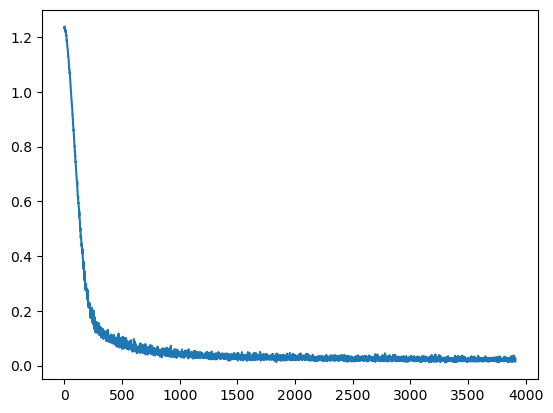

In [24]:
with open(log_file, "r") as f:
    all_loss = [float(line) for line in f]
num_rec = len(all_loss) * 10 // num_epochs
plt.plot(all_loss[:num_rec])

## 使用训练好的模型生成图像 (Image generation with trained model)

现在让我们使用上面训练好的模型 (U-Net) 来创建图像。

正如我上面提到的，图像是通过以下过程生成的。

1. 选取白噪声 $\mathbf{x}_T$，例如 $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0},\mathbf{I})$
2. 循环以下过程 $t=T,\ldots,1$
    - 选取 $\mathbf{z}$，例如当 $t>1$ 时 $\mathbf{z} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$，否则 $\mathbf{z} = \mathbf{0}$
    - $\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{1-\alpha_t}{\sqrt{1-\overline{\alpha}_t}} \epsilon_{\theta}(\mathbf{x}_t,t) \right) + \sigma_t \mathbf{z}$ ，其中 $\sigma_t^2 = \frac{(1-\alpha_t)(1-\overline{\alpha}_{t-1})}{1-\overline{\alpha}_t}$
3. 获得的（生成的）$\mathbf{x}_0$ 将成为最终的无噪声图像。

我注意到下面注释中的每个步骤编号都对应于上面的编号。

> 注意 : 正如你在这里看到的，DDPM 中的生成过程非常慢，因为逆向扩散过程需要大量的降噪迭代。<br>
> [DDIM](https://arxiv.org/pdf/2010.02502) (Denoising Diffusion Implicit Models) 是一项发明，通过将马尔可夫扩散过程转换为非马尔可夫过程，减少了生成模型所需的迭代次数。

100%|██████████| 1000/1000 [01:02<00:00, 16.03it/s]


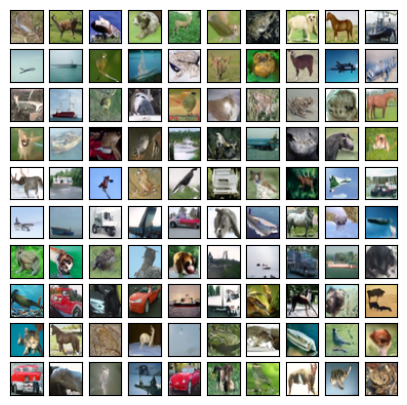

In [22]:
import tqdm

def run_inference(unet, num_images):
    unet.eval()
    # 0. generate sigma_t
    alpha_bars_prev = torch.cat((torch.ones(1).to(device), alpha_bars[:-1]))
    sigma_t_squared = (1.0 - alphas) * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)
    sigma_t = torch.sqrt(sigma_t_squared)
    # 1. make white noise
    x = torch.randn(num_images, 3, 32, 32).to(device)
    # 2. loop
    #   (t == 0 means diffused for 1 step)
    with torch.no_grad():
        for t in tqdm.tqdm(reversed(range(T)), total=T):
            if t > 0:
                z = torch.randn_like(x).to(device)
            else:
                z = torch.zeros_like(x).to(device)
            t_batch = (torch.tensor(t).to(device)).repeat(num_images)
            epsilon = unet(x, t_batch)
            x = (1.0 / torch.sqrt(alphas[t])).float() * (x - ((1.0 - alphas[t]) / torch.sqrt(1.0 - alpha_bars[t])).float() * epsilon) + \
                sigma_t[t].float() * z

    # reshape to channels-last : (N,C,H,W) --> (N,H,W,C)
    x = x.permute(0, 2, 3, 1)

    # clip
    x = torch.clamp(x, min=0.0, max=1.0)

    return x

# initialize
num_row = 10
num_col = 10
# generate images
x = run_inference(unet, num_row * num_col)
# draw
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
for i in range(num_row*num_col):
    image = x[i].cpu().numpy()
    row = i//num_col
    col = i%num_col
    ax = axes[row, col]
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(image)